In [20]:
import torch
import numpy as np
import pandas as pd
from transformers import (
    DistilBertTokenizer, 
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

In [12]:
# Check available device
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"\n GPU Available: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"\n MPS (Apple Silicon GPU) Available")
    print(f"   Your M3 Mac will use GPU acceleration!")
else:
    device = torch.device("cpu")
    print(f"\n Using CPU (training will be slower)")

print(f"   Device: {device}")
print(f"   PyTorch version: {torch.__version__}")

# Check memory
if device.type == "mps":
    print(f"\n M3 Mac uses unified memory (RAM shared with GPU)")
    print(f"   Recommended batch size: 16")



 MPS (Apple Silicon GPU) Available
   Your M3 Mac will use GPU acceleration!
   Device: mps
   PyTorch version: 2.5.1

 M3 Mac uses unified memory (RAM shared with GPU)
   Recommended batch size: 16


### Loading Cleaned Data

In [5]:
print("="*80)
print("LOADING DATA")
print("="*80)

# Loading the cleaned, balanced dataset
data_path = '../data/processed/cleaned_books_balanced.csv'
df = pd.read_csv(data_path)

print(f"\n Data loaded successfully!")
print(f"   Total samples: {len(df):,}")
print(f"   Columns: {df.columns.tolist()}")


print(f"\n Genre Distribution:")
print(df['genre'].value_counts())

# Preparing features and labels
texts = df['description'].tolist()
labels = df['genre_label'].tolist()

GENRE_NAMES = sorted(df['genre'].unique())
num_labels = len(GENRE_NAMES)

print(f"\n Classification Task:")
print(f"   Number of genres: {num_labels}")
print(f"   Genres: {GENRE_NAMES}")
print(f"   Sample text length: {np.mean([len(t) for t in texts]):.0f} characters")

LOADING DATA

 Data loaded successfully!
   Total samples: 9,848
   Columns: ['title', 'description', 'genre', 'genre_label']

 Genre Distribution:
genre
Horror             1231
Romance            1231
Biography          1231
Fantasy            1231
Self-Help          1231
Mystery            1231
Fiction            1231
Science Fiction    1231
Name: count, dtype: int64

 Classification Task:
   Number of genres: 8
   Genres: ['Biography', 'Fantasy', 'Fiction', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Self-Help']
   Sample text length: 888 characters


### Train-Test Split

In [6]:
print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Spliting data 
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, 
    labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels  
)

print(f"\n Data Split Complete:")
print(f"   Training samples: {len(train_texts):,}")
print(f"   Test samples: {len(test_texts):,}")
print(f"   Split ratio: 80/20")


print(f"\n Training Set Distribution:")
train_dist = pd.Series(train_labels).value_counts().sort_index()
for genre_id, count in train_dist.items():
    print(f"   Genre {genre_id}: {count:,} samples")

print(f"\n Test Set Distribution:")
test_dist = pd.Series(test_labels).value_counts().sort_index()
for genre_id, count in test_dist.items():
    print(f"   Genre {genre_id}: {count:,} samples")

TRAIN-TEST SPLIT

 Data Split Complete:
   Training samples: 7,878
   Test samples: 1,970
   Split ratio: 80/20

 Training Set Distribution:
   Genre 0: 985 samples
   Genre 1: 985 samples
   Genre 2: 985 samples
   Genre 3: 984 samples
   Genre 4: 985 samples
   Genre 5: 985 samples
   Genre 6: 984 samples
   Genre 7: 985 samples

 Test Set Distribution:
   Genre 0: 246 samples
   Genre 1: 246 samples
   Genre 2: 246 samples
   Genre 3: 247 samples
   Genre 4: 246 samples
   Genre 5: 246 samples
   Genre 6: 247 samples
   Genre 7: 246 samples


### Tokenization

In [7]:
print("="*80)
print("TOKENIZATION")
print("="*80)

# Loading DistilBERT tokenizer
print("\n Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenization parameters
MAX_LENGTH = 256  # Maximum sequence length 

print(f"\n  Tokenization Settings:")
print(f"   Model: distilbert-base-uncased")
print(f"   Max length: {MAX_LENGTH} tokens")
print(f"   Padding: Yes")
print(f"   Truncation: Yes")

# Tokenizing training data
print(f"\n  Tokenizing training data...")
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

# Tokenizing test data
print(f" Tokenizing test data...")
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

print(f"\n Tokenization Complete!")
print(f"   Training tokens shape: {train_encodings['input_ids'].shape}")
print(f"   Test tokens shape: {test_encodings['input_ids'].shape}")

#  Examples of  tokenization
print(f"\n Example Tokenization:")
example_text = train_texts[0][:100]
example_tokens = tokenizer.tokenize(example_text)
print(f"   Original text: {example_text}...")
print(f"   Number of tokens: {len(example_tokens)}")
print(f"   First 10 tokens: {example_tokens[:10]}")

TOKENIZATION

 Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]


  Tokenization Settings:
   Model: distilbert-base-uncased
   Max length: 256 tokens
   Padding: Yes
   Truncation: Yes

  Tokenizing training data...
 Tokenizing test data...

 Tokenization Complete!
   Training tokens shape: torch.Size([7878, 256])
   Test tokens shape: torch.Size([1970, 256])

 Example Tokenization:
   Original text: Martha Stewart is an undeniable force in the business world. One of the world's greatest entrepreneu...
   Number of tokens: 25
   First 10 tokens: ['martha', 'stewart', 'is', 'an', 'und', '##enia', '##ble', 'force', 'in', 'the']


### Creating Dataset Class

In [9]:
print("="*80)
print("CREATING PYTORCH DATASETS")
print("="*80)

class BookGenreDataset(torch.utils.data.Dataset):
    """
    Custom Dataset for book genre classification
    """
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    
    def __getitem__(self, idx):
        # Get one sample
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

# Creating dataset objects
train_dataset = BookGenreDataset(train_encodings, train_labels)
test_dataset = BookGenreDataset(test_encodings, test_labels)

print(f"\n Datasets Created:")
print(f"   Training dataset: {len(train_dataset):,} samples")
print(f"   Test dataset: {len(test_dataset):,} samples")

# Testing dataset access
print(f"\n Sample Data Point:")
sample = train_dataset[0]
print(f"   Keys: {sample.keys()}")
print(f"   Input IDs shape: {sample['input_ids'].shape}")
print(f"   Label: {sample['labels'].item()} (Genre: {GENRE_NAMES[sample['labels'].item()]})")

CREATING PYTORCH DATASETS

 Datasets Created:
   Training dataset: 7,878 samples
   Test dataset: 1,970 samples

 Sample Data Point:
   Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
   Input IDs shape: torch.Size([256])
   Label: 7 (Genre: Self-Help)


### Load DistilBERT Model

In [13]:
print("="*80)
print("LOADING DISTILBERT MODEL")
print("="*80)


# Loading model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

# Moving model to device (MPS)
model = model.to(device)

print(f"\n Model Loaded Successfully!")
print(f"   Model: DistilBERT-base-uncased")
print(f"   Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"   Number of output classes: {num_labels}")
print(f"   Device: {device}")

# Model architecture
print(f"\n Model Architecture:")
print(f"   - DistilBERT base (6 layers)")
print(f"   - Hidden size: 768")
print(f"   - Classification head: 768 → {num_labels}")

LOADING DISTILBERT MODEL


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Model Loaded Successfully!
   Model: DistilBERT-base-uncased
   Number of parameters: 66,959,624
   Trainable parameters: 66,959,624
   Number of output classes: 8
   Device: mps

 Model Architecture:
   - DistilBERT base (6 layers)
   - Hidden size: 768
   - Classification head: 768 → 8


### Defining  Training Arguments

In [ ]:
print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

# Estimating training time
samples_per_epoch = len(train_dataset)
batch_size = 16
num_epochs = 3
steps_per_epoch = samples_per_epoch // batch_size

print(f"\n Training Time Estimation (M3 Mac with MPS):")
print(f"   Samples per epoch: {samples_per_epoch:,}")
print(f"   Batch size: {batch_size}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Number of epochs: {num_epochs}")
print(f"   Estimated time per epoch: ~6-10 minutes")
print(f"   Total estimated time: ~20-30 minutes")

# Training arguments
training_args = TrainingArguments(
    output_dir='./results/distilbert',          # Where to save model
    num_train_epochs=num_epochs,                 # Number of epochs
    per_device_train_batch_size=batch_size,      # Batch size for training
    per_device_eval_batch_size=batch_size,       # Batch size for evaluation
    learning_rate=5e-5,                          # Learning rate
    weight_decay=0.01,                           # Regularization
    warmup_steps=100,                            # Gradual learning rate warmup
    logging_dir='./logs/distilbert',             # Logging directory
    logging_steps=50,                            # Logging every 50 steps
    eval_strategy="epoch",                 # Evaluating after each epoch
    save_strategy="epoch",                       # Saving after each epoch
    load_best_model_at_end=True,                 # Loading best model at end
    metric_for_best_model="accuracy",            # Metric to determine best model
    save_total_limit=2,                          # Only keeping 2 best checkpoints
    report_to="none",                            
    seed=42,                                     # Random seed
    fp16=False,                                  
)

print(f"\nTraining Configuration:")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Weight decay: {training_args.weight_decay}")
print(f"   Warmup steps: {training_args.warmup_steps}")
print(f"   Evaluation: Every epoch")
print(f"   Saveing  Best 2 models only")

TRAINING CONFIGURATION

 Training Time Estimation (M3 Mac with MPS):
   Samples per epoch: 7,878
   Batch size: 16
   Steps per epoch: 492
   Number of epochs: 3
   Estimated time per epoch: ~6-10 minutes
   Total estimated time: ~20-30 minutes

Training Configuration:
   Learning rate: 5e-05
   Batch size: 16
   Epochs: 3
   Weight decay: 0.01
   Warmup steps: 100
   Evaluation: Every epoch
   Saves: Best 2 models only


### Defining Metrics Function

In [17]:
print("="*80)
print("DEFINING EVALUATION METRICS")
print("="*80)

def compute_metrics(eval_pred):
    """
    Compute metrics during training
    """
    predictions, labels = eval_pred
    
    # Getting predicted class (argmax of logits)
    predictions = np.argmax(predictions, axis=1)
    
    # Calculating metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions, 
        average='weighted'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("\n Metrics Function Defined:")
print("   - Accuracy")
print("   - Precision (weighted)")
print("   - Recall (weighted)")
print("   - F1-Score (weighted)")

DEFINING EVALUATION METRICS

 Metrics Function Defined:
   - Accuracy
   - Precision (weighted)
   - Recall (weighted)
   - F1-Score (weighted)


### Creating Trainer  and Starting  Training 

In [18]:
print("="*80)
print("INITIALIZING TRAINER")
print("="*80)

# Creating Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print(f"\n Trainer Initialized!")
print(f"   Model: DistilBERT")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Validation samples: {len(test_dataset):,}")

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)


import time
start_time = time.time()

# Train the model
train_result = trainer.train()

# Calculate training time
end_time = time.time()
training_time = end_time - start_time

print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)
print(f"\n Training Time: {training_time/60:.2f} minutes ({training_time:.0f} seconds)")
print(f"\n Training Results:")
print(f"   Final Loss: {train_result.training_loss:.4f}")

# Display training history
if hasattr(trainer.state, 'log_history'):
    print(f"\n Training History:")
    for log in trainer.state.log_history[-5:]:  # Show last 5 logs
        if 'loss' in log:
            print(f"   Step {log.get('step', 'N/A')}: Loss = {log['loss']:.4f}")
        if 'eval_accuracy' in log:
            print(f"   Epoch {log.get('epoch', 'N/A')}: "
                  f"Accuracy = {log['eval_accuracy']:.4f}, "
                  f"F1 = {log.get('eval_f1', 0):.4f}")

INITIALIZING TRAINER

 Trainer Initialized!
   Model: DistilBERT
   Training samples: 7,878
   Validation samples: 1,970

STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.026500,1.032486,0.639086,0.677364,0.639086,0.640322
2,0.780200,0.960875,0.677665,0.672694,0.677665,0.673229
3,0.476800,1.015840,0.681218,0.683793,0.681218,0.681941



 TRAINING COMPLETE!

 Training Time: 12.83 minutes (770 seconds)

 Training Results:
   Final Loss: 0.8401

 Training History:
   Step 1350: Loss = 0.4012
   Step 1400: Loss = 0.4544
   Step 1450: Loss = 0.4768
   Epoch 3.0: Accuracy = 0.6812, F1 = 0.6819


### Evaluation on Test Set

In [29]:
print("="*80)
print("EVALUATING MODEL ON TEST SET")
print("="*80)

# Evaluating
eval_result = trainer.evaluate()

print(f"\n Test Set Performance:")
print(f"   Accuracy: {eval_result['eval_accuracy']:.4f} ({eval_result['eval_accuracy']*100:.2f}%)")
print(f"   Precision: {eval_result['eval_precision']:.4f}")
print(f"   Recall: {eval_result['eval_recall']:.4f}")
print(f"   F1-Score: {eval_result['eval_f1']:.4f}")
print(f"   Loss: {eval_result['eval_loss']:.4f}")

# Getting predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# Detailed classification report
print(f"\n Detailed Classification Report:")
print("\n" + classification_report(
    y_true, 
    y_pred, 
    target_names=GENRE_NAMES,
    digits=4
))

EVALUATING MODEL ON TEST SET



 Test Set Performance:
   Accuracy: 0.6812 (68.12%)
   Precision: 0.6838
   Recall: 0.6812
   F1-Score: 0.6819
   Loss: 1.0158

 Detailed Classification Report:

                 precision    recall  f1-score   support

        Fiction     0.7729    0.7886    0.7807       246
        Mystery     0.5720    0.5976    0.5845       246
        Romance     0.5055    0.5569    0.5300       246
Science Fiction     0.7207    0.6478    0.6823       247
        Fantasy     0.6752    0.6423    0.6583       246
         Horror     0.7306    0.7276    0.7291       246
      Biography     0.6822    0.6518    0.6667       247
      Self-Help     0.8110    0.8374    0.8240       246

       accuracy                         0.6812      1970
      macro avg     0.6838    0.6813    0.6819      1970
   weighted avg     0.6838    0.6812    0.6819      1970



### Confusion Matrix Evaluation 

CONFUSION MATRIX


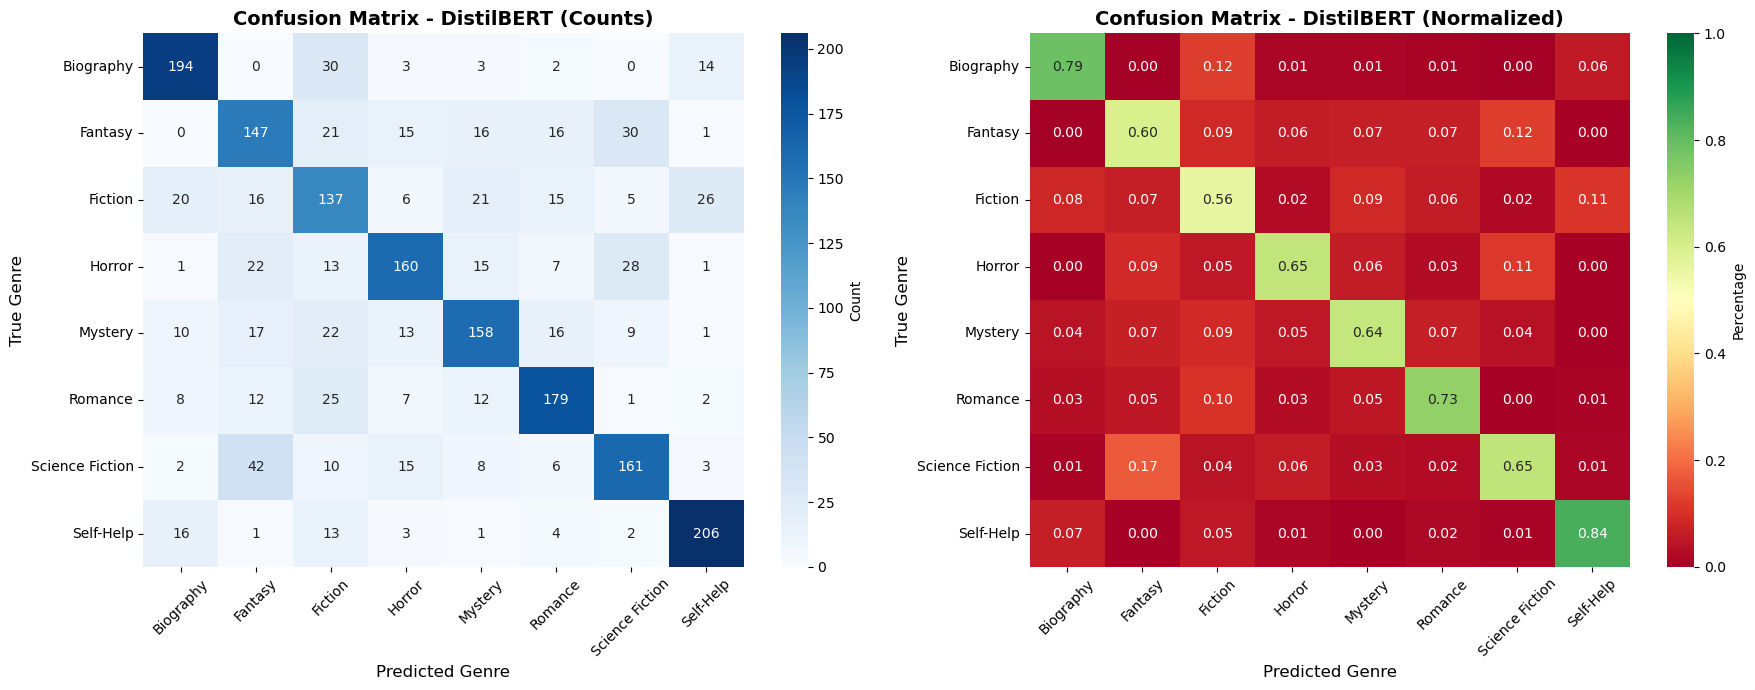

In [21]:
print("="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculating confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Creating figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix - DistilBERT (Counts)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Genre', fontsize=12)
axes[0].set_ylabel('True Genre', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Normalized
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            vmin=0, vmax=1, cbar_kws={'label': 'Percentage'}, ax=axes[1])
axes[1].set_title('Confusion Matrix - DistilBERT (Normalized)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Genre', fontsize=12)
axes[1].set_ylabel('True Genre', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Saving the Model 

In [26]:
print("="*80)
print("SAVING MODEL")
print("="*80)

from pathlib import Path

# Base directories 
MODEL_DIR = Path("../models/distilbert_genre")
RESULTS_DIR = Path("../results/distilbert")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Saving model and tokenizer
model_save_path = MODEL_DIR / "final_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"\n  Model Saved:")
print(f"   Path: {model_save_path}")

# Saving predictions
predictions_df = pd.DataFrame({
    'text': test_texts,
    'true_genre': [GENRE_NAMES[i] for i in y_true],
    'predicted_genre': [GENRE_NAMES[i] for i in y_pred],
    'correct': y_true == y_pred
})

pred_save_path = RESULTS_DIR / "predictions.csv"
predictions_df.to_csv(pred_save_path, index=False)
print(f"\n Predictions Saved: {pred_save_path}")

# Saving metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (min)'],
    'Value': [
        eval_result['eval_accuracy'],
        eval_result['eval_precision'],
        eval_result['eval_recall'],
        eval_result['eval_f1'],
        training_time / 60
    ]
})

metrics_save_path = RESULTS_DIR / "metrics.csv"
metrics_df.to_csv(metrics_save_path, index=False)
print(f" Metrics Saved: {metrics_save_path}")

print("\n ALL FILES SAVED SUCCESSFULLY!")


SAVING MODEL

  Model Saved:
   Path: ../models/distilbert_genre/final_model

 Predictions Saved: ../results/distilbert/predictions.csv
 Metrics Saved: ../results/distilbert/metrics.csv

 ALL FILES SAVED SUCCESSFULLY!


### Testing on new Samples 

In [27]:
print("="*80)
print("TESTING ON NEW BOOK DESCRIPTIONS")
print("="*80)

# Function to predict genre
def predict_genre(text):
    """Predict genre for a new book description"""
    # Tokenizing
    inputs = tokenizer(text, return_tensors="pt", truncation=True, 
                      padding=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predicting
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # Getting top prediction
    predicted_class = torch.argmax(predictions, dim=1).item()
    confidence = predictions[0][predicted_class].item()
    
    return GENRE_NAMES[predicted_class], confidence, predictions[0].cpu().numpy()

# Test examples
test_examples = [
    "A thrilling detective story where a private investigator solves a complex murder case in Victorian London.",
    "Two people from different worlds fall in love against all odds in this heartwarming contemporary romance.",
    "An epic journey through magical realms filled with dragons, wizards, and ancient prophecies.",
    "A comprehensive guide to improving your productivity and achieving your personal goals.",
    "The inspiring true story of a civil rights leader who changed the course of history."
]

print("\n. Testing Model on Sample Descriptions:\n")

for i, example in enumerate(test_examples, 1):
    genre, confidence, probs = predict_genre(example)
    
    print(f"Example {i}:")
    print(f"   Description: {example[:80]}...")
    print(f"   Predicted Genre: {genre}")
    print(f"   Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"   Top 3 predictions:")
    
    top_3 = np.argsort(probs)[-3:][::-1]
    for rank, idx in enumerate(top_3, 1):
        print(f"      {rank}. {GENRE_NAMES[idx]}: {probs[idx]:.4f}")
    print()

TESTING ON NEW BOOK DESCRIPTIONS

. Testing Model on Sample Descriptions:

Example 1:
   Description: A thrilling detective story where a private investigator solves a complex murder...
   Predicted Genre: Mystery
   Confidence: 0.9715 (97.15%)
   Top 3 predictions:
      1. Mystery: 0.9715
      2. Horror: 0.0119
      3. Science Fiction: 0.0061

Example 2:
   Description: Two people from different worlds fall in love against all odds in this heartwarm...
   Predicted Genre: Romance
   Confidence: 0.9711 (97.11%)
   Top 3 predictions:
      1. Romance: 0.9711
      2. Mystery: 0.0148
      3. Fiction: 0.0055

Example 3:
   Description: An epic journey through magical realms filled with dragons, wizards, and ancient...
   Predicted Genre: Fantasy
   Confidence: 0.7110 (71.10%)
   Top 3 predictions:
      1. Fantasy: 0.7110
      2. Science Fiction: 0.2396
      3. Mystery: 0.0184

Example 4:
   Description: A comprehensive guide to improving your productivity and achieving your persona